
## Kadada-X: Rice Leaf Disease Model - Inference Test

This notebook demonstrates how to load the trained Kadada-X model and use it to predict the disease class of a single rice leaf image.

In [2]:
# Import necessary libraries and project modules

import os
import sys
from PIL import Image
import matplotlib.pyplot as plt
import torch

project_root = os.path.abspath(os.getcwd()) # Assuming notebook is in project root
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added '{project_root}' to sys.path")

from configs import base_config as cfg
from model_pipeline.inference_utils import predict_rice_leaf_disease, load_inference_model
from data_handling.dataset_loader import create_leaf_disease_dataloaders

print("Libraries imported successfully...!!!")

Added '/home/abdullahi.isaahmed/Kadada-X' to sys.path
Libraries imported successfully...!!!


In [ ]:
# ## 1. Configuration and Model Loading

# --- Load Class Names ---
if not cfg.LEAF_DISEASE_CLASSES:
    print("cfg.LEAF_DISEASE_CLASSES is not populated. Attempting to load from dataset...")
    try:
        # Ensure cfg.DATASET_ROOT_PATH is correct in your configs/base_config.py
        _, _, discovered_classes = create_leaf_disease_dataloaders(cfg.DATASET_ROOT_PATH)
        cfg.LEAF_DISEASE_CLASSES = discovered_classes
        if not cfg.LEAF_DISEASE_CLASSES:
            raise ValueError("Could not discover classes.")
        print(f"Successfully loaded class names: {cfg.LEAF_DISEASE_CLASSES}")
    except Exception as e:
        print(f"Warning: Could not automatically load class names: {e}")


num_classes_for_model = len(cfg.LEAF_DISEASE_CLASSES) if cfg.LEAF_DISEASE_CLASSES else None
if num_classes_for_model is None:
    print("CRITICAL: Number of classes could not be determined. Predictions will likely fail or be incorrect.")


# --- Load the Model ---
# This will use cfg.MODEL_SAVE_DIRECTORY and cfg.MODEL_NAME to find the best model.
# Ensure these are correct in configs/base_config.py
print(f"Attempting to load model for {num_classes_for_model or 'inferred'} classes...")
kadada_x_loaded_model = load_inference_model(
    model_weights_path= "...../Kadada-X/results/saved_models_resnet/KadadaX_Vision_v1.pth", # Set to a specific .pth file path if not using default best
    num_classes= num_classes_for_model # Pass the number of classes
)

if kadada_x_loaded_model:
    print("Kadada-X model loaded successfully for inference!")
else:
    print("ERROR: Model could not be loaded. Check paths in configs/base_config.py and ensure a model is trained and saved.")


cfg.LEAF_DISEASE_CLASSES is not populated. Attempting to load from dataset...
Discovered classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Total images found: 120
Splitting dataset: 84 for training, 36 for validation.
Training DataLoader: 3 batches, 84 images
Validation DataLoader: 2 batches, 36 images
Successfully loaded class names: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Attempting to load model for 3 classes...
Loading Kadada-X inference model with 3 classes from /home/abdullahi.isaahmed/Kadada-X/results/saved_models_resnet/KadadaX_Vision_v1.pth...


/home/abdullahi.isaahmed/.conda/envs/kadadaX/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/abdullahi.isaahmed/.conda/envs/kadadaX/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model weights loaded from: /home/abdullahi.isaahmed/Kadada-X/results/saved_models_resnet/KadadaX_Vision_v1.pth and model moved to cpu.
Kadada-X inference model loaded successfully.
Kadada-X model loaded successfully for inference!


/home/abdullahi.isaahmed/Kadada-X/utils/general_helpers.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_architecture_instance.load_state_dict(torch.load(model_wei

### Perform Prediction
This cell loads the specified image, preprocesses it, and predicts the disease class.


Processing image: /home/abdullahi.isaahmed/Kadada-X/other_images/rice_image_0001.jpg

--- Prediction Result ---
  Predicted Disease Class: Leaf smut
  Confidence Score: 0.8510 (85.10%)

  Probabilities for all classes:
    - Bacterial leaf blight: 0.0220
    - Brown spot: 0.1270
    - Leaf smut: 0.8510


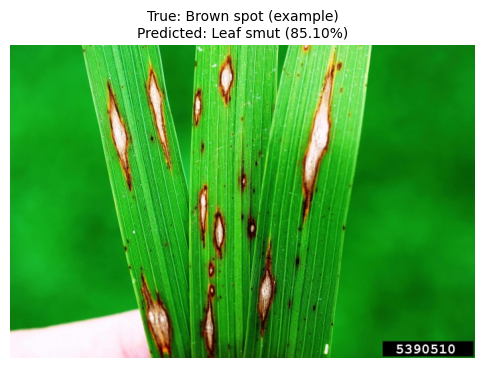

In [ ]:


# Define the image path before using it
# ENSURE THIS PATH IS CORRECT AND THE IMAGE EXISTS
image_path_to_test = "..../Kadada-X/other_images/rice_image_0001.jpg"
# image_path_to_test = "..../Kadada-X/rice_leaf_diseases_df/Leaf smut/DSC_0507.jpg"
# image_path_to_test = ".../Kadada-X/istockphoto-2111604430-612x612.jpg"

if 'kadada_x_loaded_model' in locals() and kadada_x_loaded_model is not None:
    if image_path_to_test and os.path.exists(image_path_to_test):
        print(f"Processing image: {image_path_to_test}")
        # Load the image using PIL (already done if you pass the path directly)
        # test_image_pil = Image.open(image_path_to_test).convert("RGB") # You can pass the path or PIL image

        # Perform prediction using the function from inference_utils
        # The function expects either a path to an image or a PIL Image object
        predicted_label, confidence, all_class_probs_list = predict_rice_leaf_disease(
            image_input=image_path_to_test,      # Pass the image path or a PIL image
            model_instance=kadada_x_loaded_model, # Corrected argument name
            class_names_list=cfg.LEAF_DISEASE_CLASSES # Corrected argument name
        )

        if "Error" not in predicted_label:
            # Display the results
            print(f"\n--- Prediction Result ---")
            print(f"  Predicted Disease Class: {predicted_label}")
            print(f"  Confidence Score: {confidence:.4f} ({confidence*100:.2f}%)")

            print("\n  Probabilities for all classes:")
            if cfg.LEAF_DISEASE_CLASSES and all_class_probs_list:
                for i, class_name_iter in enumerate(cfg.LEAF_DISEASE_CLASSES):
                    print(f"    - {class_name_iter}: {all_class_probs_list[i]:.4f}")
            else:
                print(f"    Raw probabilities list: {all_class_probs_list}")

            # Show the image (load it again here for display if you passed the path)
            display_image = Image.open(image_path_to_test).convert("RGB")
            plt.figure(figsize=(6,6))
            plt.imshow(display_image)
            plt.axis('off')
            plt.title(f"True: Brown spot (example)\nPredicted: {predicted_label} ({confidence*100:.2f}%)", fontsize=10)
            plt.show()


In [ ]:
# !pip install -q -U google-genai

In [ ]:
# from google import genai

# # YOUR_API_KEY = xxxx-xxxx-xxxxx-xxxxx-

# # client = genai.Client(api_key="YOUR_API_KEY")

# client = genai.Client(api_key="YOUR_API_KEY")

# response = client.models.generate_content(
#     model="gemini-2.0-flash", contents="Explain how AI works in a few words"
# )
# print(response.text)

In [ ]:
# --- Define the disease name ---
# This is the variable that will be inserted into your prompt
disease_name = "Rice Blast"  

prompt_content = f"""You are an expert agricultural advisor for rice diseases.
A rice plant has '{disease_name}'.

Provide a concise, actionable list of management and prevention strategies for this disease.
Prioritize methods that are environmentally friendly and sustainable.

Structure your advice using bullet points under these categories:
- Cultural Practices
- Biological Control
- Chemical Control (emphasize this as a last resort)

The advice should be suitable for small to medium-scale farmers.
"""

from google import genai

client = genai.Client(api_key="xxxx-xxxx-xxxxx-xxxxx-xxxx")

response = client.models.generate_content(
    model="gemini-2.0-flash", contents= prompt_content #"Explain how AI works in a few words"
)
print(response.text)

Okay, here's a concise, actionable list of management and prevention strategies for rice blast, prioritizing environmentally friendly and sustainable methods, suitable for small to medium-scale farmers:

**Cultural Practices:**

*   **Use Resistant Varieties:** This is the *most important* and sustainable method. Choose rice varieties known to be resistant to blast races prevalent in your region. Consult with your local agricultural extension officer for the best options.
*   **Balanced Fertilization:** Avoid excessive nitrogen fertilizer. Use a balanced fertilizer regime based on soil testing. Too much nitrogen can increase plant susceptibility to blast. Ensure adequate potassium and silicon levels.
*   **Water Management:**
    *   *Avoid* prolonged periods of drought stress *or* continuous flooding. Alternate wetting and drying (AWD) irrigation can reduce humidity and sporulation.
    *   Ensure good drainage in fields to prevent waterlogging.
*   **Seed Health:**
    *   Use certif